<a href="https://colab.research.google.com/github/joselitopapi14/clasificador-rutas/blob/main/Clasificador_frutas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive

In [ ]:
# 1. Montar el almacenamiento persistente
drive.mount('/content/drive')

# 2. Crear la estructura del proyecto
base_dir = '/content/drive/MyDrive/Proyecto_ML_Frescura'
raw_dir = os.path.join(base_dir, 'data/raw')
processed_dir = os.path.join(base_dir, 'data/processed')

os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

print(f"Estructura creada en: {base_dir}")

Mounted at /content/drive
Estructura creada en: /content/drive/MyDrive/Proyecto_ML_Frescura


In [ ]:
# 1. Configurar la nueva autenticación de Kaggle (Reemplaza con tu token exacto)
!mkdir -p ~/.kaggle && echo KGAT_3cfd60814630eaabce6a9cf2e56fb455 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

# 2. Descargar el dataset (Esto guardará el .zip en el almacenamiento temporal ultrarrápido de Colab)
!kaggle datasets download -d ibneshihab/fruit-and-vegetable-freshness-dataset

# 3. Mover el .zip a tu almacenamiento persistente de Drive
!mv fruit-and-vegetable-freshness-dataset.zip /content/drive/MyDrive/Proyecto_ML_Frescura/data/raw/

Dataset URL: https://www.kaggle.com/datasets/ibneshihab/fruit-and-vegetable-freshness-dataset
License(s): MIT
100% 29.6G/29.6G [05:11<00:00, 102MB/s] 



In [4]:
import zipfile
import os

# Ruta donde guardaste el zip en Drive
zip_path = '/content/drive/MyDrive/Proyecto_ML_Frescura/data/raw/fruit-and-vegetable-freshness-dataset.zip'

# Carpeta de extracción temporal ultrarrápida en Colab
extract_dir = '/content/dataset_temp'
os.makedirs(extract_dir, exist_ok=True)

print("Iniciando extracción. Esto puede tomar unos minutos debido al tamaño (30GB)...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("¡Extracción completada!")

Iniciando extracción. Esto puede tomar unos minutos debido al tamaño (30GB)...
¡Extracción completada!


Buscando imágenes en todas las subcarpetas...

--- Distribución del Dataset ---
Clase 'Banana Formalin-mixed': 10560 imágenes
Clase 'Malabar Healthy': 576 imágenes
Clase 'Fresh Jujube': 600 imágenes
Clase 'Orange Fresh': 12048 imágenes
Clase 'Apple Fresh': 12240 imágenes
Clase 'Mango Formalin-mixed': 9856 imágenes
Clase 'Banana Rotten': 10112 imágenes
Clase 'Fresh Guava': 600 imágenes
Clase 'Fresh Cucumber': 2408 imágenes
Clase 'Rotten Cucumber': 2252 imágenes
Clase 'Orange Rotten': 10496 imágenes
Clase 'Rotten Bellpepper': 2364 imágenes
Clase 'Rotten Tomato': 2380 imágenes
Clase 'Fresh Strawberry': 2612 imágenes
Clase 'Malabar Unhealthy': 792 imágenes
Clase 'Bean Healthy': 2528 imágenes
Clase 'Fresh Pomegranate': 600 imágenes
Clase 'Fresh Potato': 2448 imágenes
Clase 'Rotten Potato': 2336 imágenes
Clase 'Apple Rotten': 1336 imágenes
Clase 'Cauliflower Unhealthy': 640 imágenes
Clase 'Apple Formalin-mixed': 3928 imágenes
Clase 'Fresh Tomato': 2412 imágenes
Clase 'Orange Formalin-mixed':

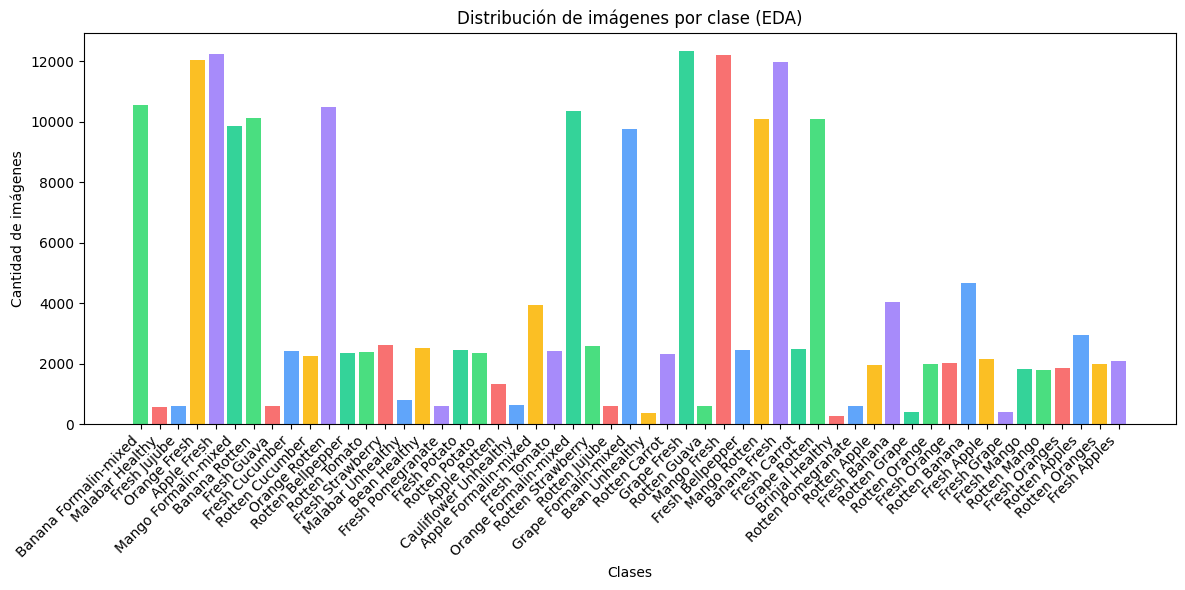


--- Muestras Aleatorias ---


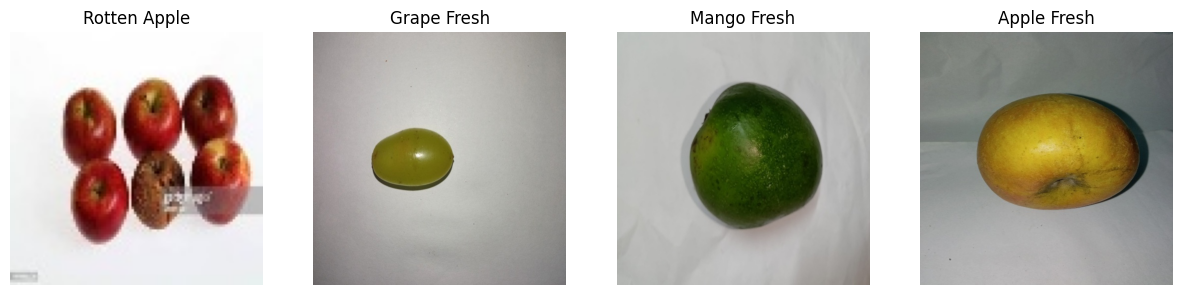

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from collections import Counter

dataset_path = Path('/content/dataset_temp')

print("Buscando imágenes en todas las subcarpetas...")
# 1. Obtener todas las imágenes de forma recursiva (esto ya sabemos que funciona)
todas_las_imagenes = list(dataset_path.rglob('*.jpg')) + list(dataset_path.rglob('*.png')) + list(dataset_path.rglob('*.jpeg'))

if not todas_las_imagenes:
    print("No se encontraron imágenes. Verifica que la ruta y la extracción sean correctas.")
else:
    # 2. Extraer el nombre de la carpeta padre de cada imagen (esta es la etiqueta/clase)
    # Por ejemplo: si la ruta es /content/dataset_temp/train/freshapples/img1.jpg, extraerá 'freshapples'
    clases_extraidas = [img_path.parent.name for img_path in todas_las_imagenes]

    # 3. Contar cuántas imágenes hay por clase automáticamente
    conteo_clases = Counter(clases_extraidas)

    # Separar en listas para graficar
    clases = list(conteo_clases.keys())
    conteos = list(conteo_clases.values())

    print("\n--- Distribución del Dataset ---")
    for clase, conteo in conteo_clases.items():
        print(f"Clase '{clase}': {conteo} imágenes")

    # 4. Graficar la distribución
    plt.figure(figsize=(12, 6))
    plt.bar(clases, conteos, color=['#4ade80', '#f87171', '#60a5fa', '#fbbf24', '#a78bfa', '#34d399'][:len(clases)])
    plt.title('Distribución de imágenes por clase (EDA)')
    plt.xlabel('Clases')
    plt.ylabel('Cantidad de imágenes')
    plt.xticks(rotation=45, ha='right') # Rota el texto para que no se superpongan si hay muchas clases
    plt.tight_layout() # Ajusta los márgenes
    plt.show()

    # 5. Visualizar muestras aleatorias
    print("\n--- Muestras Aleatorias ---")
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))

    for ax in axes:
        # Escoger una imagen al azar
        img_path = random.choice(todas_las_imagenes)
        img = mpimg.imread(str(img_path))
        ax.imshow(img)
        ax.set_title(img_path.parent.name)
        ax.axis('off')
    plt.show()

In [7]:
from PIL import Image
import os

imagenes_corruptas = []

print("Verificando la integridad de las imágenes... (Esto puede tardar unos minutos)")
for img_path in todas_las_imagenes:
    try:
        # Abre la imagen y verifica los bytes de la cabecera sin cargarla toda en RAM
        with Image.open(img_path) as img:
            img.verify()
    except Exception as e:
        imagenes_corruptas.append(img_path)

print(f"Se encontraron {len(imagenes_corruptas)} imágenes corruptas.")

# Eliminar las imágenes dañadas para evitar errores en el entrenamiento
if imagenes_corruptas:
    for img_path in imagenes_corruptas:
        try:
            os.remove(img_path)
        except OSError as e:
            print(f"Error al eliminar {img_path}: {e}")
    print("Todas las imágenes corruptas han sido eliminadas del entorno temporal.")
else:
    print("¡El dataset está limpio! Ninguna imagen está corrupta.")

Verificando la integridad de las imágenes... (Esto puede tardar unos minutos)
Se encontraron 0 imágenes corruptas.
¡El dataset está limpio! Ninguna imagen está corrupta.


In [8]:
requirements_path = '/content/drive/MyDrive/Proyecto_ML_Frescura/requirements.txt'

with open(requirements_path, 'w') as f:
    f.write("matplotlib\n")
    f.write("Pillow\n")

print(f"requirements.txt guardado en: {requirements_path}")

requirements.txt guardado en: /content/drive/MyDrive/Proyecto_ML_Frescura/requirements.txt


In [9]:
import os
import shutil
from pathlib import Path

# Definir directorios
base_dir = Path('/content/dataset_temp')
clean_dir = Path('/content/dataset_clean')
clean_dir.mkdir(exist_ok=True)

# Diccionario de mapeo basado exactamente en las clases que encontraste
# Homologamos "Healthy" a "Fresh" y "Unhealthy" a "Rotten" para mantener estándar el modelo
mapeo_clases = {
    # Manzanas
    'Apple Fresh': 'Apple_Fresh', 'Fresh Apple': 'Apple_Fresh', 'Fresh Apples': 'Apple_Fresh',
    'Apple Rotten': 'Apple_Rotten', 'Rotten Apple': 'Apple_Rotten', 'Rotten Apples': 'Apple_Rotten',
    'Apple Formalin-mixed': 'Apple_Formalin',
    # Naranjas
    'Orange Fresh': 'Orange_Fresh', 'Fresh Orange': 'Orange_Fresh', 'Fresh Oranges': 'Orange_Fresh',
    'Orange Rotten': 'Orange_Rotten', 'Rotten Orange': 'Orange_Rotten', 'Rotten Oranges': 'Orange_Rotten',
    'Orange Formalin-mixed': 'Orange_Formalin',
    # Bananos
    'Banana Fresh': 'Banana_Fresh', 'Fresh Banana': 'Banana_Fresh',
    'Banana Rotten': 'Banana_Rotten', 'Rotten Banana': 'Banana_Rotten',
    'Banana Formalin-mixed': 'Banana_Formalin',
    # Mangos
    'Mango Fresh': 'Mango_Fresh', 'Fresh Mango': 'Mango_Fresh',
    'Mango Rotten': 'Mango_Rotten', 'Rotten Mango': 'Mango_Rotten',
    'Mango Formalin-mixed': 'Mango_Formalin',
    # Uvas
    'Grape Fresh': 'Grape_Fresh', 'Fresh Grape': 'Grape_Fresh',
    'Grape Rotten': 'Grape_Rotten', 'Rotten Grape': 'Grape_Rotten',
    'Grape Formalin-mixed': 'Grape_Formalin',
    # Fresas
    'Fresh Strawberry': 'Strawberry_Fresh', 'Rotten Strawberry': 'Strawberry_Rotten',
    # Tomates
    'Fresh Tomato': 'Tomato_Fresh', 'Rotten Tomato': 'Tomato_Rotten',
    # Papas
    'Fresh Potato': 'Potato_Fresh', 'Rotten Potato': 'Potato_Rotten',
    # Zanahorias
    'Fresh Carrot': 'Carrot_Fresh', 'Rotten Carrot': 'Carrot_Rotten',
    # Pepinos
    'Fresh Cucumber': 'Cucumber_Fresh', 'Rotten Cucumber': 'Cucumber_Rotten',
    # Pimentones
    'Fresh Bellpepper': 'Bellpepper_Fresh', 'Rotten Bellpepper': 'Bellpepper_Rotten',
    # Guayabas
    'Fresh Guava': 'Guava_Fresh', 'Rotten Guava': 'Guava_Rotten',
    # Granadas
    'Fresh Pomegranate': 'Pomegranate_Fresh', 'Rotten Pomegranate': 'Pomegranate_Rotten',
    # Azufaifas (Jujube)
    'Fresh Jujube': 'Jujube_Fresh', 'Rotten Jujube': 'Jujube_Rotten',
    # Otros vegetales
    'Malabar Healthy': 'Malabar_Fresh', 'Malabar Unhealthy': 'Malabar_Rotten',
    'Bean Healthy': 'Bean_Fresh', 'Bean Unhealthy': 'Bean_Rotten',
    'Cauliflower Unhealthy': 'Cauliflower_Rotten',
    'Brinjal Healthy': 'Brinjal_Fresh'
}

print("Reorganizando, fusionando y estandarizando carpetas...")

imagenes_movidas = 0

for old_class, new_class in mapeo_clases.items():
    new_class_path = clean_dir / new_class
    new_class_path.mkdir(exist_ok=True)

    # Buscar todas las carpetas que coincidan con el nombre antiguo
    for old_path in base_dir.rglob(old_class):
        if old_path.is_dir():
            for img_file in old_path.glob('*.*'):
                if img_file.is_file():
                    # Renombrar el archivo al moverlo para evitar que se sobrescriban
                    # si dos carpetas viejas tienen imágenes llamadas "image_1.jpg"
                    new_file_name = f"{old_class.replace(' ', '_')}_{img_file.name}"
                    shutil.move(str(img_file), str(new_class_path / new_file_name))
                    imagenes_movidas += 1

print(f"¡Éxito! Se unificaron {imagenes_movidas} imágenes.")
print("Tu dataset final listo para entrenar está en: /content/dataset_clean")

Reorganizando, fusionando y estandarizando carpetas...
¡Éxito! Se unificaron 216297 imágenes.
Tu dataset final listo para entrenar está en: /content/dataset_clean


In [10]:
requirements_path = '/content/drive/MyDrive/Proyecto_ML_Frescura/requirements.txt'
with open(requirements_path, 'w') as f:
    f.write("matplotlib\n")
    f.write("Pillow\n")
print(f"Archivo creado en {requirements_path}")

Archivo creado en /content/drive/MyDrive/Proyecto_ML_Frescura/requirements.txt


In [11]:
import shutil
import os

# Definir las rutas
carpeta_limpia = '/content/dataset_clean'
zip_local = '/content/dataset_clean_final' # shutil le agregará la extensión .zip
destino_drive = '/content/drive/MyDrive/Proyecto_ML_Frescura/data/processed/dataset_clean_final.zip'

print("1. Comprimiendo más de 200,000 imágenes en el entorno local... (Esto tomará varios minutos)")
shutil.make_archive(zip_local, 'zip', carpeta_limpia)

print("2. Transfiriendo el archivo comprimido a Google Drive...")
# Mover el archivo desde el disco temporal al almacenamiento persistente
shutil.move(f"{zip_local}.zip", destino_drive)

print(f"¡Protección completada! Tu dataset limpio y unificado está a salvo en:\n{destino_drive}")

1. Comprimiendo más de 200,000 imágenes en el entorno local... (Esto tomará varios minutos)
2. Transfiriendo el archivo comprimido a Google Drive...
¡Protección completada! Tu dataset limpio y unificado está a salvo en:
/content/drive/MyDrive/Proyecto_ML_Frescura/data/processed/dataset_clean_final.zip
